# Notebook 03 · XGBoost Virtual Sensing for Gap Imputation

**Goal:** Fill structural gaps in the `absinc` inclinometer series using an
XGBoost virtual sensing model trained on physics-validated proxy regressors
(ERA5-Land skin temperature, surface solar radiation, relative humidity),
cyclic time encodings, and autoregressive lags of the target.

**Key design choice:** The model is trained and predicts in the **first-difference
domain** (Δy_t = y_t − y_{t−1}). The level is reconstructed by cumulative sum
seeded from the last observed value before each gap. This eliminates systematic
level bias: anchoring is structural rather than post-hoc, and prediction error
accumulates as a zero-mean random walk rather than a deterministic offset.

**Steps:**
1. Data Overview — visualise the full series with gap regions highlighted.
2. Feature Engineering — build the XGBoost input matrix on observed data.
3. Model Training — fit XGBoost on all observed rows.
4. Internal Validation — synthetic gap test with reconstruction metrics
   and proxy-correlation preservation check.
5. Uncertainty Quantification — bootstrap ensemble for prediction intervals.
6. Gap Imputation — iterative one-step-ahead imputation for all gap blocks.
7. Save Outputs — reconstructed series and uncertainty estimates.

In [51]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.abspath('..'))
from heritageshm.viz import apply_theme

apply_theme(context='notebook')

# ── Paths ──────────────────────────────────────────────────────────────────────
FULL_DATA_PATH    = "data/interim/aligned/st02_aligned_dataset.csv"
OUTPUT_PATH       = "data/processed/absinc_imputed.csv"
UNCERTAINTY_PATH  = "data/processed/absinc_imputed_uncertainty.csv"
FIG_PATH          = "outputs/figures/"

os.makedirs(FIG_PATH, exist_ok=True)
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

# ── Config ────────────────────────────────────────────────────────────────────
TARGET       = "absinc"
PROXY_COLS   = [
    "skin_temperature (degC)",
    "surface_solar_radiation (W/m^2)",
    "relative_humidity (0-1)",
]
PROXY_LAGS   = {
    "skin_temperature (degC)":          2,
    "surface_solar_radiation (W/m^2)":  1,
    "relative_humidity (0-1)":          0,
}
AR_LAGS         = [1, 2, 6, 12, 24]
GAP_DURATION_H  = 168      # synthetic validation gap length (7 days)
N_BOOTSTRAP     = 50
RANDOM_SEED     = 42

XGB_PARAMS = dict(
    n_estimators     = 500,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = RANDOM_SEED,
    n_jobs           = -1,
)

## Step 1 · Data Overview

In [52]:
df_full = pd.read_csv(FULL_DATA_PATH, parse_dates=["datetime"], index_col="datetime")

# Reindex onto a complete regular hourly grid
full_idx = pd.date_range(df_full.index.min(), df_full.index.max(), freq="1h")
df_full  = df_full.reindex(full_idx)

# ── CHANGED: compute first-difference column once ────────────────────────────
# The model is trained to predict Δy_t = y_t − y_{t-1}.
# NaN at gap boundaries is expected and handled during training/imputation.
df_full[f"{TARGET}_diff"] = df_full[TARGET].diff()
TARGET_DIFF = f"{TARGET}_diff"
# ─────────────────────────────────────────────────────────────────────────────

print(f"Full dataset   : {df_full.shape[0]} rows | "
      f"{df_full.index[0]} → {df_full.index[-1]}")
print(f"Total NaN in target      : {df_full[TARGET].isna().sum()} "
      f"({df_full[TARGET].isna().mean()*100:.1f}%)")
print(f"Target diff column added : {TARGET_DIFF}  "
      f"(non-NaN: {df_full[TARGET_DIFF].notna().sum()})")

# ── Proxy data coverage ──────────────────────────────────────────────────────
proxy_missing  = df_full[PROXY_COLS].isna().any(axis=1)
target_missing = df_full[TARGET].isna()
both_missing   = proxy_missing & target_missing
proxy_ok_gap   = (~proxy_missing) & target_missing

print(f"\nProxy availability during target gaps:")
print(f"  Target missing AND proxy also missing : {both_missing.sum()} h "
      f"({both_missing.sum()/target_missing.sum()*100:.1f}% of gaps)")
print(f"  Target missing AND proxy available    : {proxy_ok_gap.sum()} h "
      f"({proxy_ok_gap.sum()/target_missing.sum()*100:.1f}% of gaps)")

Full dataset   : 57278 rows | 2018-07-25 23:00:00 → 2025-02-05 12:00:00
Total NaN in target      : 17503 (30.6%)
Target diff column added : absinc_diff  (non-NaN: 39370)

Proxy availability during target gaps:
  Target missing AND proxy also missing : 0 h (0.0% of gaps)
  Target missing AND proxy available    : 17503 h (100.0% of gaps)


In [53]:
def get_gap_blocks(series):
    is_gap    = series.isna()
    gap_start = series.index[is_gap & ~is_gap.shift(1,  fill_value=False)]
    gap_end   = series.index[is_gap & ~is_gap.shift(-1, fill_value=False)]
    blocks    = pd.DataFrame({"start": gap_start, "end": gap_end})
    blocks["duration_h"] = (
        (blocks["end"] - blocks["start"]).dt.total_seconds() / 3600 + 1
    )
    return blocks.reset_index(drop=True)

gap_blocks = get_gap_blocks(df_full[TARGET])
print(f"\nDetected {len(gap_blocks)} gap blocks")
print(f"Longest gap : {gap_blocks['duration_h'].max():.0f} h  "
      f"({gap_blocks['duration_h'].max()/24:.1f} days)")
print(f"Total missing : {gap_blocks['duration_h'].sum():.0f} h")


Detected 404 gap blocks
Longest gap : 10501 h  (437.5 days)
Total missing : 17503 h


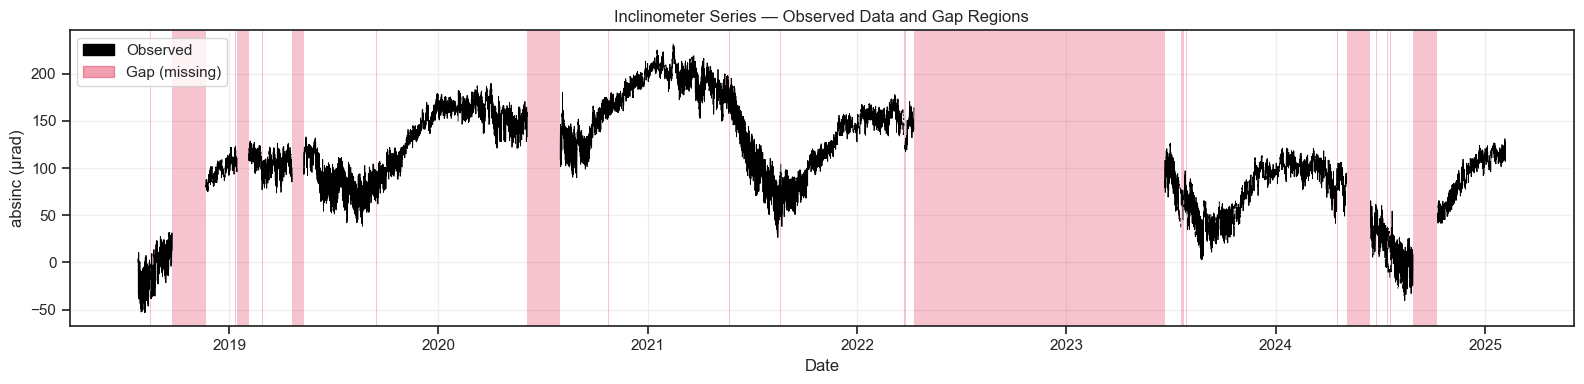

In [54]:
# Chart 1 — Full series with gap regions
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_full.index, df_full[TARGET], color="black", linewidth=0.6,
        label="Observed")
for _, row in gap_blocks.iterrows():
    ax.axvspan(row["start"], row["end"], color="crimson", alpha=0.25, linewidth=0)
obs_patch = mpatches.Patch(color="black",  label="Observed")
gap_patch = mpatches.Patch(color="crimson", alpha=0.4, label="Gap (missing)")
ax.legend(handles=[obs_patch, gap_patch], loc="upper left")
ax.set_title("Inclinometer Series — Observed Data and Gap Regions")
ax.set_xlabel("Date")
ax.set_ylabel("absinc (µrad)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "03_01_gap_overview.png"), dpi=150)
plt.show()

## Step 2 · Feature Engineering (training matrix on observed data only)

In [55]:
# ── CHANGED: build_feature_row now accepts working_diff ─────────────────────
# AR lags are computed on the DIFFERENCED target (working_diff), not the level.
# Proxy values and time encodings are unchanged.
def build_feature_row(ts, working_series, working_diff, df_source,
                       proxy_lags, ar_lags, target_diff_col):
    """
    Build a single-row feature dict for timestamp `ts`.

    - Proxy values    : always from df_source (original dataset, never imputed).
    - AR lags         : from working_diff (first differences of the running
                        reconstructed level — includes Δy of prior predictions
                        inside gaps).
    - Time encodings  : derived from ts directly.

    Note: working_series is no longer used for AR lags but is kept as an
    argument to allow callers to optionally inspect the level series.
    """
    row = {}

    # Proxy regressors at their validated optimal lags
    for proxy, lag in proxy_lags.items():
        lag_ts = ts - pd.Timedelta(hours=lag)
        row[f"{proxy}_lag{lag}"] = (
            df_source[proxy].get(lag_ts, np.nan)
            if lag_ts in df_source.index else np.nan
        )

    # Cyclic time encodings
    row["hour_sin"]  = np.sin(2 * np.pi * ts.hour / 24)
    row["hour_cos"]  = np.cos(2 * np.pi * ts.hour / 24)
    row["doy_sin"]   = np.sin(2 * np.pi * ts.dayofyear / 365.25)
    row["doy_cos"]   = np.cos(2 * np.pi * ts.dayofyear / 365.25)
    row["month_sin"] = np.sin(2 * np.pi * ts.month / 12)
    row["month_cos"] = np.cos(2 * np.pi * ts.month / 12)

    # AR lags on the DIFFERENCED target
    for lag in ar_lags:
        lag_ts = ts - pd.Timedelta(hours=lag)
        row[f"{target_diff_col}_lag{lag}"] = (
            working_diff.get(lag_ts, np.nan)
            if lag_ts in working_diff.index else np.nan
        )

    return row


# ── CHANGED: build_training_matrix uses TARGET_DIFF as the shift source ─────
def build_training_matrix(df, proxy_lags, ar_lags, target_diff_col):
    """
    Build the vectorised training feature matrix.
    AR lags are computed on target_diff_col (Δy), not the level.
    Used only for training — iterative prediction uses build_feature_row.
    """
    X = pd.DataFrame(index=df.index)

    # Proxy regressors at optimal lags
    for proxy, lag in proxy_lags.items():
        X[f"{proxy}_lag{lag}"] = df[proxy].shift(lag)

    # Cyclic time encodings
    X["hour_sin"]  = np.sin(2 * np.pi * df.index.hour / 24)
    X["hour_cos"]  = np.cos(2 * np.pi * df.index.hour / 24)
    X["doy_sin"]   = np.sin(2 * np.pi * df.index.dayofyear / 365.25)
    X["doy_cos"]   = np.cos(2 * np.pi * df.index.dayofyear / 365.25)
    X["month_sin"] = np.sin(2 * np.pi * df.index.month / 12)
    X["month_cos"] = np.cos(2 * np.pi * df.index.month / 12)

    # AR lags on the DIFFERENCED target
    for lag in ar_lags:
        X[f"{target_diff_col}_lag{lag}"] = df[target_diff_col].shift(lag)

    return X


# ── CHANGED: y_full is now the differenced target ───────────────────────────
X_full = build_training_matrix(df_full, PROXY_LAGS, AR_LAGS, TARGET_DIFF)
y_full = df_full[TARGET_DIFF]   # model predicts Δy, not level

# Training mask: rows where both X and y are fully observed
train_mask = y_full.notna() & X_full.notna().all(axis=1)
X_train    = X_full[train_mask]
y_train    = y_full[train_mask]

print(f"Training samples : {len(X_train)}")
print(f"Feature columns  : {X_full.shape[1]}")

# Print feature list
feature_types = []
for col in X_full.columns:
    if TARGET_DIFF in col:                                      # ── CHANGED
        ftype = "Autoregressive (Δy)"
    elif any(p.split(" ")[0] in col for p in PROXY_COLS):
        ftype = "Proxy (physics)"
    else:
        ftype = "Time encoding"
    feature_types.append({"Feature": col, "Type": ftype})

print("\n── Table 1 · Feature List ──────────────────────────────────")
print(pd.DataFrame(feature_types).to_string(index=False))

Training samples : 36483
Feature columns  : 14

── Table 1 · Feature List ──────────────────────────────────
                             Feature                Type
        skin_temperature (degC)_lag2     Proxy (physics)
surface_solar_radiation (W/m^2)_lag1     Proxy (physics)
        relative_humidity (0-1)_lag0     Proxy (physics)
                            hour_sin       Time encoding
                            hour_cos       Time encoding
                             doy_sin       Time encoding
                             doy_cos       Time encoding
                           month_sin       Time encoding
                           month_cos       Time encoding
                    absinc_diff_lag1 Autoregressive (Δy)
                    absinc_diff_lag2 Autoregressive (Δy)
                    absinc_diff_lag6 Autoregressive (Δy)
                   absinc_diff_lag12 Autoregressive (Δy)
                   absinc_diff_lag24 Autoregressive (Δy)


## Step 3 · XGBoost Training

In [56]:
model = XGBRegressor(**XGB_PARAMS)
model.fit(X_train, y_train, verbose=False)

train_pred = model.predict(X_train)
# ── CHANGED: metrics are in the Δy domain ───────────────────────────────────
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
train_r2   = r2_score(y_train, train_pred)
print(f"Training RMSE (Δy domain) : {train_rmse:.4f}")
print(f"Training R²   (Δy domain) : {train_r2:.4f}")
print(f"\nNote: R² on differences is structurally lower than on levels.")
print(f"Reconstruction quality is evaluated on levels in Step 4.")

# Compute training residual std for conformal interval calibration
# Residuals are in the Δy domain — their std governs prediction error per step.
train_residuals = y_train.values - train_pred
residual_std    = train_residuals.std()
print(f"\nTraining residual std σ_cal (Δy domain) : {residual_std:.4f}  "
      f"← used for conformal interval calibration")

Training RMSE (Δy domain) : 1.9221
Training R²   (Δy domain) : 0.6680

Note: R² on differences is structurally lower than on levels.
Reconstruction quality is evaluated on levels in Step 4.

Training residual std σ_cal (Δy domain) : 1.9221  ← used for conformal interval calibration


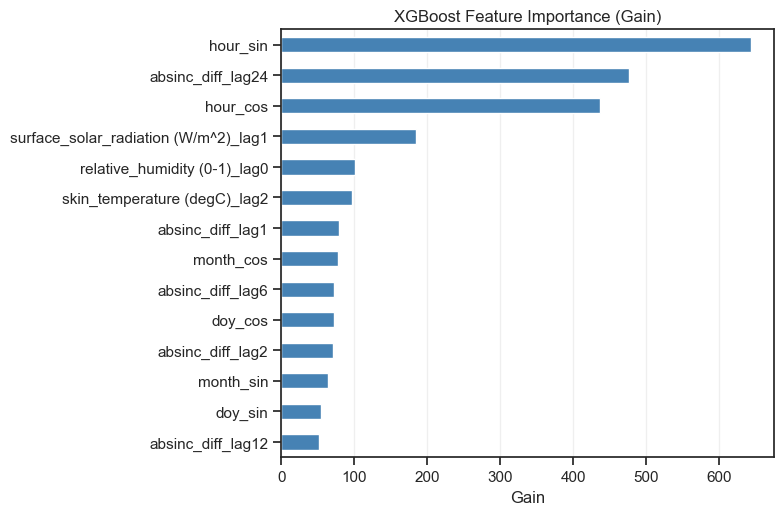

In [57]:
# Chart 2 — Feature importance (gain)
importance = pd.Series(
    model.get_booster().get_score(importance_type="gain"),
    name="Gain"
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(importance) * 0.38)))
importance.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("XGBoost Feature Importance (Gain)")
ax.set_xlabel("Gain")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "03_02_feature_importance.png"), dpi=150)
plt.show()

## Step 4 · Internal Validation — Synthetic Gap Test

A contiguous block of `GAP_DURATION_H` hours is masked from the training set.
The model is retrained on the remaining data and then asked to impute the
masked block using **iterative one-step-ahead prediction** in the differenced
domain, with cumsum reconstruction seeded from the last observed level.

In [58]:
# Select synthetic gap window inside the longest observed contiguous block
obs_runs  = (~df_full[TARGET].isna()).astype(int)
run_ends  = df_full.index[(obs_runs == 1) & (obs_runs.shift(-1, fill_value=0) == 0)]
run_starts= df_full.index[(obs_runs == 1) & (obs_runs.shift(1,  fill_value=0) == 0)]
run_lengths = [(e - s).total_seconds()/3600 for s, e in zip(run_starts, run_ends)]
longest_run_idx = int(np.argmax(run_lengths))
longest_start   = run_starts[longest_run_idx]
longest_end     = run_ends[longest_run_idx]

# Place synthetic gap at the centre of the longest run
run_idx     = pd.date_range(longest_start, longest_end, freq="1h")
mid         = len(run_idx) // 2
gap_idx_val = run_idx[mid - GAP_DURATION_H//2 : mid + GAP_DURATION_H//2]

print(f"Longest contiguous block : {longest_start} → {longest_end} "
      f"({run_lengths[longest_run_idx]:.0f} h)")
print(f"Synthetic gap window     : {gap_idx_val[0]} → {gap_idx_val[-1]} "
      f"({len(gap_idx_val)} h)")

Longest contiguous block : 2023-12-15 09:00:00 → 2024-03-27 09:00:00 (2472 h)
Synthetic gap window     : 2024-02-01 09:00:00 → 2024-02-08 08:00:00 (168 h)


In [59]:
# Retrain on data outside the synthetic gap
mask_val  = ~df_full.index.isin(gap_idx_val)
df_val    = df_full[mask_val].copy()
X_val_tr  = build_training_matrix(df_val, PROXY_LAGS, AR_LAGS, TARGET_DIFF)  # ── CHANGED
y_val_tr  = df_val[TARGET_DIFF]                                               # ── CHANGED
tr_mask_v = y_val_tr.notna() & X_val_tr.notna().all(axis=1)

model_val = XGBRegressor(**XGB_PARAMS)
model_val.fit(X_val_tr[tr_mask_v], y_val_tr[tr_mask_v], verbose=False)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [60]:
# ── CHANGED: impute_gap_iterative — differenced domain with cumsum reconstruction
def impute_gap_iterative(model, gap_idx, working_series, working_diff,
                          df_source, proxy_lags, ar_lags,
                          target_col, target_diff_col):
    """
    Iterative one-step-ahead imputation in the first-difference domain.

    The model predicts Δŷ_t = y_t − y_{t-1}.
    The level is reconstructed step by step as:
        ŷ_t = ŷ_{t-1} + Δŷ_t
    seeded from the last observed value immediately before the gap.

    This eliminates systematic level bias: the reconstruction is structurally
    anchored to the last real observation and drifts only as a zero-mean
    random walk (cumulative sum of prediction errors).

    Parameters
    ----------
    working_series : pd.Series
        Running level series (observed + prior imputed values).
        Updated in-place with each predicted level.
    working_diff : pd.Series
        Running first-difference series.
        Updated in-place with each predicted Δy.
        Used by build_feature_row for AR lags of Δy.
    df_source : pd.DataFrame
        Original dataset — used exclusively for proxy values.
    target_col : str
        Name of the level target column (for seed lookup).
    target_diff_col : str
        Name of the differenced target column (for AR feature names).

    Returns
    -------
    pd.Series of reconstructed level predictions indexed by gap_idx.
    Timestamps where proxy data is unavailable are returned as NaN.
    """
    predictions = {}

    # ── Seed: last observed level before the gap ─────────────────────────────
    prev_level = np.nan
    for lookback in range(1, 49):
        seed_ts  = gap_idx[0] - pd.Timedelta(hours=lookback)
        seed_val = working_series.get(seed_ts, np.nan)
        if not np.isnan(seed_val):
            prev_level = seed_val
            break

    if np.isnan(prev_level):
        # No observed seed within 48 h — cannot anchor; return all NaN
        return pd.Series({ts: np.nan for ts in gap_idx})

    # ── Iterative prediction ──────────────────────────────────────────────────
    for ts in gap_idx:
        row  = build_feature_row(ts, working_series, working_diff,
                                  df_source, proxy_lags, ar_lags,
                                  target_diff_col)
        Xrow = pd.DataFrame([row])

        if Xrow.isna().any(axis=1).values[0]:
            predictions[ts] = np.nan
            # Do not update prev_level — seed remains at last valid value
            continue

        delta_pred = float(model.predict(Xrow)[0])
        level_pred = prev_level + delta_pred

        # Write back to both working series
        working_series[ts] = level_pred
        working_diff[ts]   = delta_pred

        predictions[ts] = level_pred
        prev_level      = level_pred

    return pd.Series(predictions)


# ── CHANGED: validation call now initialises working_diff ───────────────────
working_val      = df_full[TARGET].copy()
working_val_diff = df_full[TARGET_DIFF].copy()
working_val.loc[gap_idx_val]      = np.nan
working_val_diff.loc[gap_idx_val] = np.nan

preds_val  = impute_gap_iterative(
    model_val, gap_idx_val,
    working_val, working_val_diff,
    df_full, PROXY_LAGS, AR_LAGS,
    TARGET, TARGET_DIFF
)
y_true_val = df_full[TARGET].loc[gap_idx_val]

# Drop any NaN predictions (proxy also missing) before scoring
valid_mask = preds_val.notna() & y_true_val.notna()
y_true_sc  = y_true_val[valid_mask]
y_pred_sc  = preds_val[valid_mask]

rmse = np.sqrt(mean_squared_error(y_true_sc, y_pred_sc))
mae  = mean_absolute_error(y_true_sc, y_pred_sc)
r2   = r2_score(y_true_sc, y_pred_sc)
bias = float((y_pred_sc - y_true_sc).mean())
maxe = float((y_pred_sc - y_true_sc).abs().max())

print("\n── Table 2 · Reconstruction Metrics (Synthetic Gap, level domain) ──")
metrics_df = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R²", "Max Absolute Error", "Bias (mean error)"],
    "Value":  [round(rmse,4), round(mae,4), round(r2,4), round(maxe,4), round(bias,4)]
})
print(metrics_df.to_string(index=False))


── Table 2 · Reconstruction Metrics (Synthetic Gap, level domain) ──
            Metric   Value
              RMSE 10.5339
               MAE  9.3711
                R² -2.7902
Max Absolute Error 18.5598
 Bias (mean error)  9.2154


In [61]:
# Proxy correlation preservation
print("\n── Table 3 · Proxy Correlation Preservation ────────────────")
rows = []
for proxy, lag in PROXY_LAGS.items():
    proxy_lagged = df_full[proxy].shift(lag)
    r_obs  = proxy_lagged.loc[gap_idx_val].corr(y_true_val)
    r_imp  = proxy_lagged.loc[gap_idx_val].corr(preds_val)
    rows.append({
        "Proxy":        f"{proxy} (lag {lag}h)",
        "r (observed)": round(r_obs, 3),
        "r (imputed)":  round(r_imp, 3),
        "Δr":           round(r_imp - r_obs, 3),
    })
print(pd.DataFrame(rows).to_string(index=False))


── Table 3 · Proxy Correlation Preservation ────────────────
                                   Proxy  r (observed)  r (imputed)     Δr
        skin_temperature (degC) (lag 2h)        -0.685       -0.383  0.303
surface_solar_radiation (W/m^2) (lag 1h)        -0.582       -0.837 -0.255
        relative_humidity (0-1) (lag 0h)         0.417        0.754  0.337


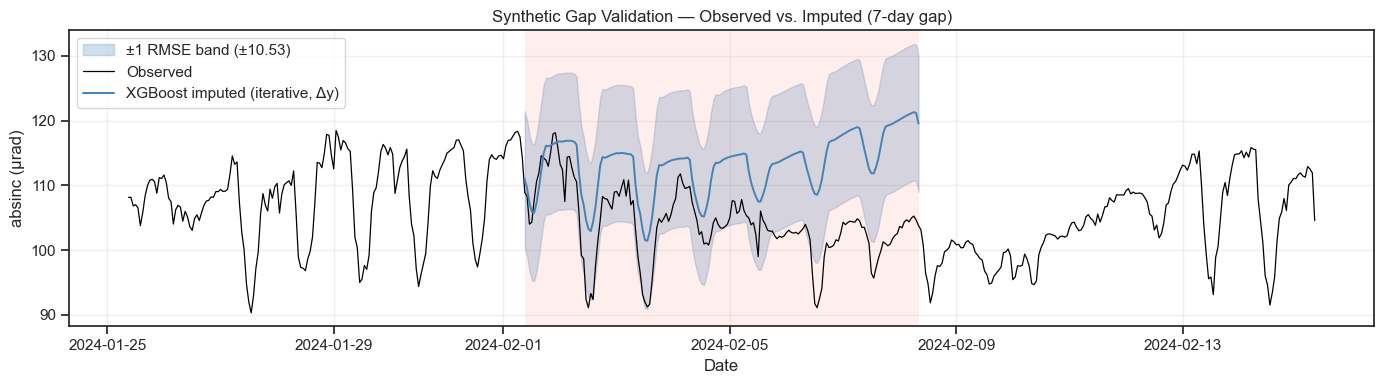

In [62]:
# Chart 3 — Synthetic gap validation: observed vs. imputed
context_start = gap_idx_val[0]  - pd.Timedelta(days=7)
context_end   = gap_idx_val[-1] + pd.Timedelta(days=7)
context_mask  = (df_full.index >= context_start) & (df_full.index <= context_end)

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(gap_idx_val[valid_mask],
                y_pred_sc - rmse, y_pred_sc + rmse,
                color="steelblue", alpha=0.25, label=f"±1 RMSE band (±{rmse:.2f})")
ax.axvspan(gap_idx_val[0], gap_idx_val[-1], color="salmon", alpha=0.12, linewidth=0)
ax.plot(df_full.index[context_mask], df_full[TARGET][context_mask],
        color="black", linewidth=0.9, label="Observed")
ax.plot(gap_idx_val[valid_mask], y_pred_sc,
        color="steelblue", linewidth=1.4, label="XGBoost imputed (iterative, Δy)")
ax.set_title(f"Synthetic Gap Validation — Observed vs. Imputed ({GAP_DURATION_H//24}-day gap)")
ax.set_xlabel("Date")
ax.set_ylabel("absinc (µrad)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "03_03_synthetic_gap_validation.png"), dpi=150)
plt.show()

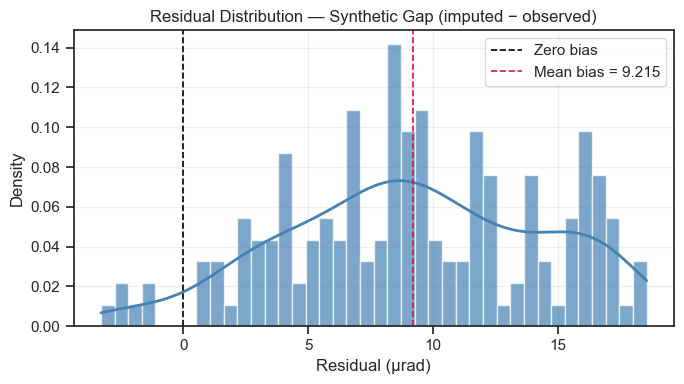

In [63]:
# Chart 4 — Residual distribution
residuals_val = (y_pred_sc - y_true_sc).values

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(residuals_val, bins=40, density=True, color="steelblue",
        edgecolor="white", alpha=0.7)
xr = np.linspace(residuals_val.min(), residuals_val.max(), 300)
ax.plot(xr, gaussian_kde(residuals_val)(xr), color="steelblue", linewidth=2)
ax.axvline(0,    color="black",   linestyle="--", linewidth=1.2, label="Zero bias")
ax.axvline(bias, color="crimson", linestyle="--", linewidth=1.2,
           label=f"Mean bias = {bias:.3f}")
ax.set_title("Residual Distribution — Synthetic Gap (imputed − observed)")
ax.set_xlabel("Residual (µrad)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "03_04_residual_distribution.png"), dpi=150)
plt.show()

## Step 5 · Uncertainty Quantification

Two complementary uncertainty estimates are produced:

**Bootstrap ensemble σ** — variance across N_BOOTSTRAP models trained on
resampled subsets of the training data. Captures model variance.

**Conformal calibration** — scales the bootstrap σ to match empirical
coverage on the training residuals (Δy domain). Ensures reported intervals
reflect actual prediction error, not just ensemble agreement.

In [64]:
boot_preds = np.full((N_BOOTSTRAP, len(gap_idx_val)), np.nan)

for b in range(N_BOOTSTRAP):
    rng      = np.random.default_rng(RANDOM_SEED + b)
    boot_idx = rng.choice(len(X_train), size=len(X_train), replace=True)
    X_b      = X_train.iloc[boot_idx]
    y_b      = y_train.iloc[boot_idx]
    m_b      = XGBRegressor(**XGB_PARAMS)
    m_b.fit(X_b, y_b, verbose=False)

    # ── CHANGED: initialise working_diff for each bootstrap replicate ────────
    working_b      = df_full[TARGET].copy()
    working_b_diff = df_full[TARGET_DIFF].copy()
    working_b.loc[gap_idx_val]      = np.nan
    working_b_diff.loc[gap_idx_val] = np.nan

    preds_b = impute_gap_iterative(
        m_b, gap_idx_val,
        working_b, working_b_diff,
        df_full, PROXY_LAGS, AR_LAGS,
        TARGET, TARGET_DIFF
    )
    boot_preds[b, :] = preds_b.values
    if (b + 1) % 10 == 0:
        print(f"  Bootstrap {b+1}/{N_BOOTSTRAP} done")

boot_mean = np.nanmean(boot_preds, axis=0)
boot_std  = np.nanstd(boot_preds,  axis=0)

# ── Conformal calibration ────────────────────────────────────────────────────
mean_boot_std   = np.nanmean(boot_std[boot_std > 0])
conformal_scale = residual_std / mean_boot_std if mean_boot_std > 0 else 1.0
boot_std_cal    = boot_std * conformal_scale

print(f"\nCalibration:")
print(f"  Mean raw bootstrap σ   : {mean_boot_std:.4f}")
print(f"  Training residual σ    : {residual_std:.4f}")
print(f"  Conformal scale factor : {conformal_scale:.3f}")

# ── Coverage on synthetic gap ────────────────────────────────────────────────
y_true_arr = y_true_val.values
valid_boot = ~np.isnan(boot_mean) & ~np.isnan(y_true_arr)

within_1s_raw = np.mean(
    (y_true_arr[valid_boot] >= boot_mean[valid_boot] - boot_std[valid_boot]) &
    (y_true_arr[valid_boot] <= boot_mean[valid_boot] + boot_std[valid_boot])
) * 100
within_2s_raw = np.mean(
    (y_true_arr[valid_boot] >= boot_mean[valid_boot] - 2*boot_std[valid_boot]) &
    (y_true_arr[valid_boot] <= boot_mean[valid_boot] + 2*boot_std[valid_boot])
) * 100
within_1s_cal = np.mean(
    (y_true_arr[valid_boot] >= boot_mean[valid_boot] - boot_std_cal[valid_boot]) &
    (y_true_arr[valid_boot] <= boot_mean[valid_boot] + boot_std_cal[valid_boot])
) * 100
within_2s_cal = np.mean(
    (y_true_arr[valid_boot] >= boot_mean[valid_boot] - 2*boot_std_cal[valid_boot]) &
    (y_true_arr[valid_boot] <= boot_mean[valid_boot] + 2*boot_std_cal[valid_boot])
) * 100

print(f"\n── Table 4 · Bootstrap Uncertainty Summary ─────────────────")
summ = pd.DataFrame({
    "Statistic": [
        "Mean raw bootstrap σ", "Conformal scale factor",
        "Mean calibrated σ",
        "% ground truth within ±1σ (raw)",   "% ground truth within ±2σ (raw)",
        "% ground truth within ±1σ (cal)",   "% ground truth within ±2σ (cal)",
        "Max calibrated σ"
    ],
    "Value": [
        round(mean_boot_std, 4), round(conformal_scale, 3),
        round(np.nanmean(boot_std_cal), 4),
        round(within_1s_raw, 1),  round(within_2s_raw, 1),
        round(within_1s_cal, 1),  round(within_2s_cal, 1),
        round(np.nanmax(boot_std_cal), 4)
    ]
})
print(summ.to_string(index=False))

  Bootstrap 10/50 done
  Bootstrap 20/50 done
  Bootstrap 30/50 done
  Bootstrap 40/50 done
  Bootstrap 50/50 done

Calibration:
  Mean raw bootstrap σ   : 3.4435
  Training residual σ    : 1.9221
  Conformal scale factor : 0.558

── Table 4 · Bootstrap Uncertainty Summary ─────────────────
                      Statistic   Value
           Mean raw bootstrap σ  3.4435
         Conformal scale factor  0.5580
              Mean calibrated σ  1.9221
% ground truth within ±1σ (raw)  7.7000
% ground truth within ±2σ (raw) 25.0000
% ground truth within ±1σ (cal)  3.0000
% ground truth within ±2σ (cal)  9.5000
               Max calibrated σ  3.5885


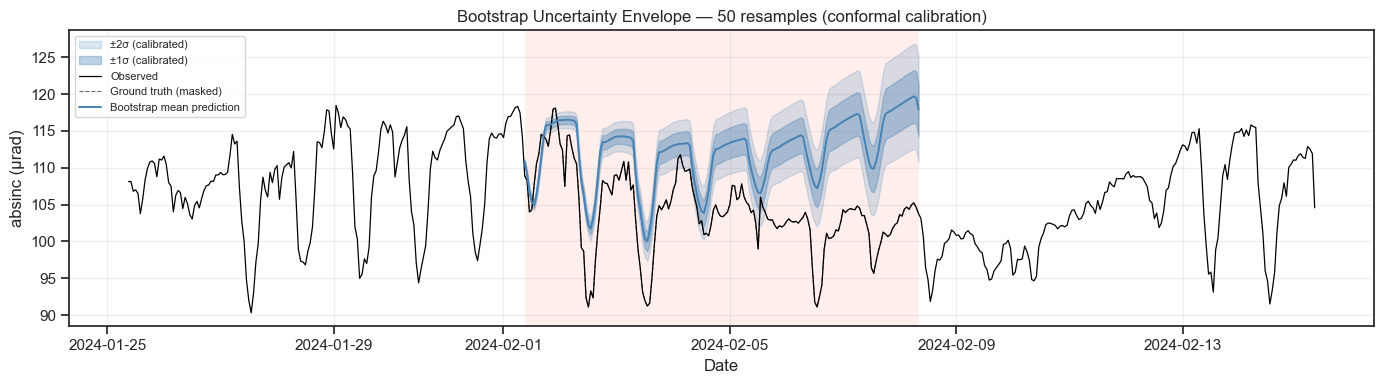

In [65]:
# Chart 5 — Bootstrap uncertainty envelope on synthetic gap
fig, ax = plt.subplots(figsize=(14, 4))
ax.axvspan(gap_idx_val[0], gap_idx_val[-1], color="salmon", alpha=0.12, linewidth=0)
ax.fill_between(gap_idx_val, boot_mean - 2*boot_std_cal, boot_mean + 2*boot_std_cal,
                color="steelblue", alpha=0.20, label="±2σ (calibrated)")
ax.fill_between(gap_idx_val, boot_mean - boot_std_cal,   boot_mean + boot_std_cal,
                color="steelblue", alpha=0.35, label="±1σ (calibrated)")
ax.plot(df_full.index[context_mask], df_full[TARGET][context_mask],
        color="black", linewidth=0.9, label="Observed")
ax.plot(gap_idx_val, y_true_val, color="black", linewidth=0.8,
        linestyle="--", alpha=0.6, label="Ground truth (masked)")
ax.plot(gap_idx_val, boot_mean, color="steelblue", linewidth=1.4,
        label="Bootstrap mean prediction")
ax.set_title(f"Bootstrap Uncertainty Envelope — {N_BOOTSTRAP} resamples "
             f"(conformal calibration)")
ax.set_xlabel("Date")
ax.set_ylabel("absinc (µrad)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "03_05_bootstrap_uncertainty.png"), dpi=150)
plt.show()

## Step 6 · Full Gap Imputation (Iterative)

All gap blocks are imputed using the same iterative one-step-ahead strategy
validated above, operating in the first-difference domain. The working series
is a single global copy of the target; predictions made for earlier gaps
propagate AR information to later gaps. The level is reconstructed by cumsum
seeded from the last observed value before each gap.

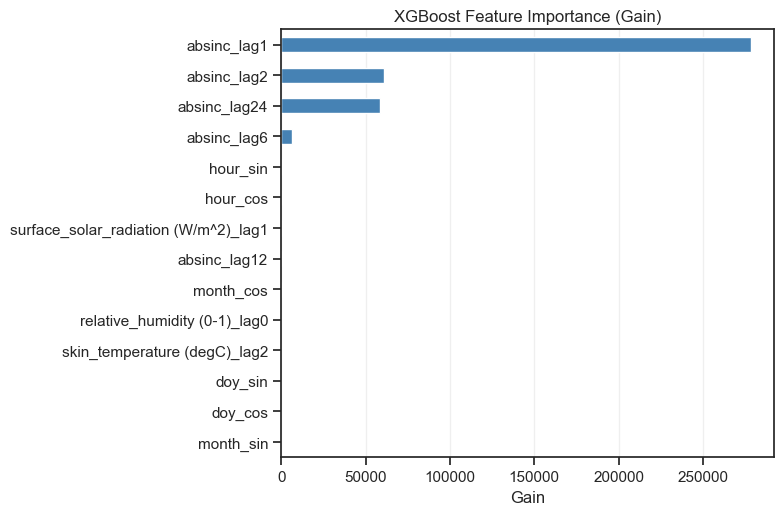

In [32]:
# ── CHANGED: initialise working_full_diff alongside working_full ─────────────
working_full      = df_full[TARGET].copy()
working_full_diff = df_full[TARGET_DIFF].copy()

imputed_flag = pd.Series(False, index=df_full.index)   # True = imputed cell
imputed_std  = pd.Series(np.nan, index=df_full.index)  # calibrated σ

log_rows = []

for gap_num, gap_row in gap_blocks.iterrows():
    gap_idx = pd.date_range(gap_row["start"], gap_row["end"], freq="1h")

    # ── Point prediction using the full model ────────────────────────────────
    preds_gap = impute_gap_iterative(
        model, gap_idx,
        working_full, working_full_diff,           # ── CHANGED
        df_full, PROXY_LAGS, AR_LAGS,
        TARGET, TARGET_DIFF                        # ── CHANGED
    )

    # Write predictions into the global working series
    # (working_full and working_full_diff are already updated in-place
    #  inside impute_gap_iterative, but we also set the flag here)
    valid_preds = preds_gap.dropna()
    imputed_flag.loc[valid_preds.index] = True

    # ── Bootstrap uncertainty for this gap ───────────────────────────────────
    boot_gap = np.full((N_BOOTSTRAP, len(gap_idx)), np.nan)
    for b in range(N_BOOTSTRAP):
        rng      = np.random.default_rng(RANDOM_SEED + b)
        boot_idx = rng.choice(len(X_train), size=len(X_train), replace=True)
        m_b      = XGBRegressor(**XGB_PARAMS)
        m_b.fit(X_train.iloc[boot_idx], y_train.iloc[boot_idx], verbose=False)
        # ── CHANGED: seed bootstrap working series from current working_full ─
        working_b      = working_full.copy()
        working_b_diff = working_full_diff.copy()
        preds_b = impute_gap_iterative(
            m_b, gap_idx,
            working_b, working_b_diff,
            df_full, PROXY_LAGS, AR_LAGS,
            TARGET, TARGET_DIFF
        )
        boot_gap[b, :] = preds_b.values

    gap_std_raw = np.nanstd(boot_gap, axis=0)
    gap_std_cal = gap_std_raw * conformal_scale
    imputed_std.loc[gap_idx] = gap_std_cal

    mean_sigma    = (
        round(float(np.nanmean(gap_std_cal)), 4)
        if not np.all(np.isnan(gap_std_cal)) else None
    )
    imputed_count = valid_preds.shape[0]

    log_rows.append({
        "Gap #":        gap_num + 1,
        "Start":        gap_row["start"].strftime("%Y-%m-%d %H:%M"),
        "End":          gap_row["end"].strftime("%Y-%m-%d %H:%M"),
        "Duration (h)": int(gap_row["duration_h"]),
        "Imputed (h)":  imputed_count,
        "Not imputed":  int(gap_row["duration_h"]) - imputed_count,
        "Mean σ (cal)": mean_sigma if mean_sigma is not None else "—",
    })

    if (gap_num + 1) % 50 == 0 or gap_num < 5:
        print(f"Gap {gap_num+1:3d}/{len(gap_blocks)} | "
              f"{int(gap_row['duration_h']):5.0f} h | "
              f"imputed {imputed_count:5d} h | "
              f"σ_cal = {mean_sigma if mean_sigma else '—'}")

In [ ]:
print("\n── Table 5 · Gap Imputation Log (first 25 + last 5) ────────")
log_df = pd.DataFrame(log_rows)
print(log_df.head(25).to_string(index=False))
print("...")
print(log_df.tail(5).to_string(index=False))

total_imputed     = log_df["Imputed (h)"].sum()
total_not_imputed = log_df["Not imputed"].sum()
print(f"\nTotal imputed    : {total_imputed} h  "
      f"({total_imputed / df_full[TARGET].isna().sum() * 100:.1f}% of all gaps)")
print(f"Total not imputed: {total_not_imputed} h  "
      f"(proxy also missing)")

In [ ]:
# Chart 6 — Full reconstructed series
df_out = df_full[[TARGET] + PROXY_COLS].copy()
df_out[TARGET] = working_full   # observed + imputed

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_full.index, df_full[TARGET],
        color="black", linewidth=0.6, label="Observed", zorder=3)
imp_idx = imputed_flag[imputed_flag].index
ax.fill_between(
    imp_idx,
    (working_full.loc[imp_idx] - imputed_std.loc[imp_idx]).values,
    (working_full.loc[imp_idx] + imputed_std.loc[imp_idx]).values,
    color="steelblue", alpha=0.3, label="±1σ uncertainty"
)
ax.scatter(imp_idx, working_full.loc[imp_idx],
           color="steelblue", s=1.2, zorder=2, label="XGBoost imputed")
ax.set_title("Full Reconstructed Inclinometer Series — Observed + Imputed")
ax.set_xlabel("Date")
ax.set_ylabel("absinc (µrad)")
ax.legend(loc="upper left", markerscale=4)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "03_06_full_reconstruction.png"), dpi=150)
plt.show()

In [ ]:
# Chart 7 — Calibrated σ over time (uncertainty profile)
fig, ax = plt.subplots(figsize=(16, 3))
ax.fill_between(df_full.index, 0, imputed_std.fillna(0),
                color="steelblue", alpha=0.6)
ax.set_title("Calibrated Uncertainty Profile — σ per Imputed Hour")
ax.set_xlabel("Date")
ax.set_ylabel("σ (µrad)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "03_07_uncertainty_profile.png"), dpi=150)
plt.show()

## Step 7 · Save Outputs

In [33]:
# Reconstructed series — working_full already contains absolute level values
# (cumsum back-transform is done inside impute_gap_iterative).
# NeuralProphet (Notebook 04) receives this file with no further transformation.
df_save = pd.DataFrame({
    "datetime":     df_full.index,
    TARGET:         working_full.values,
    "imputed_flag": imputed_flag.values,
})
df_save.to_csv(OUTPUT_PATH, index=False)
print(f"Reconstructed series saved → {OUTPUT_PATH}")

# Uncertainty estimates
df_unc = pd.DataFrame({
    "datetime":           df_full.index,
    "sigma_calibrated":   imputed_std.values,
})
df_unc.to_csv(UNCERTAINTY_PATH, index=False)
print(f"Uncertainty estimates saved → {UNCERTAINTY_PATH}")

# Summary stats
print(f"\n── Final Reconstruction Summary ────────────────────────────")
print(f"Original NaN             : {df_full[TARGET].isna().sum()} h")
print(f"Successfully imputed     : {imputed_flag.sum()} h "
      f"({imputed_flag.sum()/df_full[TARGET].isna().sum()*100:.1f}%)")
remaining_nan = working_full.isna().sum()
print(f"Remaining NaN            : {remaining_nan} h "
      f"(proxy unavailable during these gaps)")
print(f"Mean calibrated σ        : "
      f"{imputed_std.dropna().mean():.4f} µrad")

Longest contiguous block : 2023-12-15 09:00:00 → 2024-03-27 09:00:00 (2472 h)
Synthetic gap window     : 2024-02-01 09:00:00 → 2024-02-08 08:00:00 (168 h)
